In [48]:
%matplotlib ipympl
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.collections import PatchCollection, LineCollection
import os

In [2]:
from raytracer_2d import (
    get_rect_subdivs,
    get_rects_center_2d,
    get_rects_edges_2d,
    get_rects_verts_2d,
    get_fov_pixel_centers_2d,
    get_rays_2d,
    get_fov_verts_2d,
    get_verts_sorted_2d,
    get_convex_hull_2d,
    get_cuts_ray_on_edges_2d,
)

from raytracer_2d import plot_rects, plot_scanner_2d

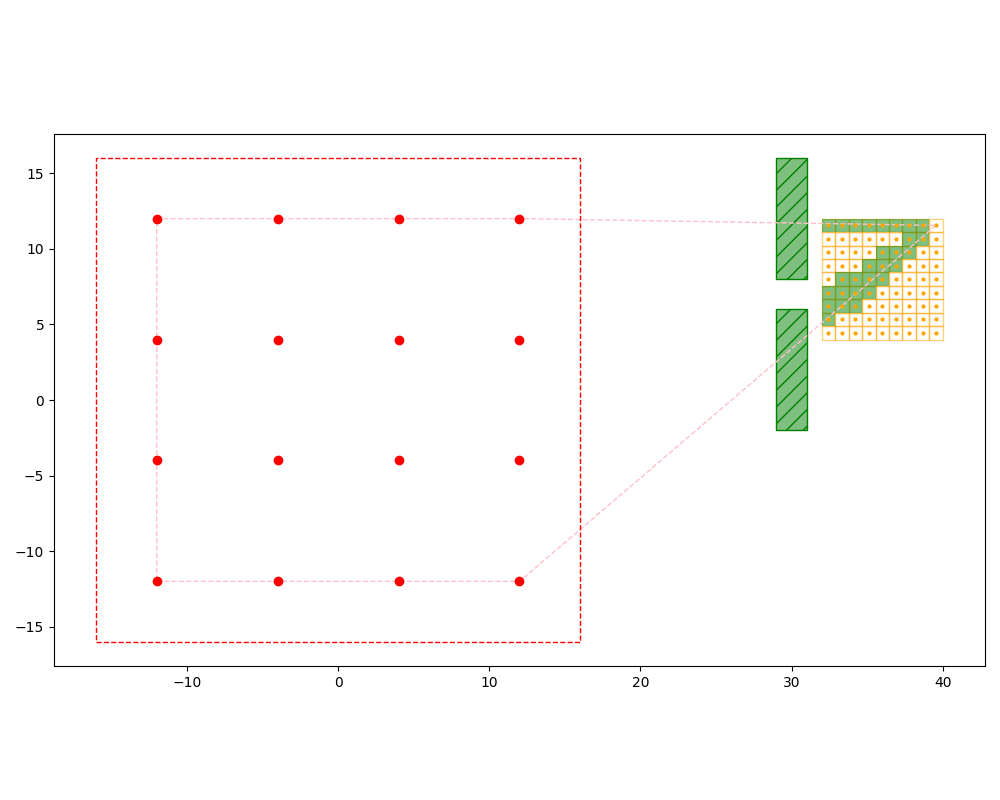

In [51]:
# define the subdivisions of the crystal
rect = torch.tensor(
    [[32, 4], [8, 0], [0, 8]],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([9, 9])

rect_subs = get_rect_subdivs(rect, xtal_nsubs)
plate_rects = torch.tensor(
    [
        [[29, 8], [2, 0], [0, 8]],
        [[29, -2], [2, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([8, 8])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor = get_fov_pixel_centers_2d(fov_npx, fov_mmppx)
pb_tensor = get_rects_center_2d(rect_subs)
rays = get_rays_2d(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2))

fov_verts = get_fov_verts_2d(fov_dims)
voxel_corners = get_convex_hull_2d(pa_tensor.view(-1, 2))


def get_cuts_ray_on_edges_2d(
    rays: torch.Tensor,
    edges: torch.Tensor,
):
    """
    Cut rays with line segments (edges)
    """
    # rays shape (number of starting points, number of end points, 2, 2)
    # `number of end points` is always 1
    # edges shape (n_rects, 4, 2, 2)
    n_pa = rays.shape[0]
    n_rects = edges.shape[0]
    v1 = (
        (rays[:, :, 1] - rays[:, :, 0])
        .view(n_pa, 1, 1, 2)
        .expand(-1, n_rects, 4, -1)
    )
    v2 = (edges[:, :, 0] - edges[:, :, 1]).unsqueeze(0).expand(n_pa, -1, -1, -1)
    v3 = edges[:, :, 0].unsqueeze(0).expand(n_pa, -1, -1, -1) - rays[
        :, :, 0
    ].view(n_pa, 1, 1, 2).expand(-1, n_rects, 4, -1)
  
    # cramer's rule
    # v1, v2, v3 shape (n_pa, n_rects, 4, 2)
    # det shape (n_pa, n_rects, 4)
    det = v1[:, :, :, 0] * v2[:, :, :, 1] - v1[:, :, :, 1] * v2[:, :, :, 0]
    t = torch.where(
        det != 0,
        (v3[:, :, :, 0] * v2[:, :, :, 1] - v2[:, :, :, 0] * v3[:, :, :, 1])
        / det,
        float("nan"),
    )
    s = torch.where(
        det != 0,
        (v1[:, :, :, 0] * v3[:, :, :, 1] - v1[:, :, :, 1] * v3[:, :, :, 0])
        / det,
        float("nan"),
    )
    t = torch.where((s <= 1) * (s >= 0) * (t <= 1) * (t >= 0), t, float("nan"))
    index = torch.argwhere(~torch.isnan(t))
    return t, index


def if_rects_intersect_hull_2d(rects, hull, sub_center):
    # get the edges of the rectangles
    edges = get_rects_edges_2d(rects)
    index = torch.argsort(torch.linalg.norm(hull - sub_center, dim=1))
    ends = hull[index[1:5]]
    rays = get_rays_2d(ends, sub_center.view(1, 2))
    _, index = get_cuts_ray_on_edges_2d(rays, edges)
    return torch.unique(index[:, 1])

def plot_rays(ax, rays, **kwargs):
    line_segments = LineCollection(rays, **kwargs)
    ax.add_collection(line_segments)
        
i_list = torch.arange(0, rect_subs.shape[0])
# i_list = [7]
for i in i_list:
    candidates = torch.vstack(
        (plate_rects, rect_subs[~torch.arange(rect_subs.shape[0]).eq(i)])
    )

    candidates_verts = get_rects_verts_2d(candidates)
    hull = get_verts_sorted_2d(
        get_convex_hull_2d(torch.vstack((pb_tensor[i], voxel_corners)))
    )
    valid_indices = if_rects_intersect_hull_2d(candidates, hull, pb_tensor[i])
    try:
        plt.close()
    except Exception as e:
        pass
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.set_aspect("equal")
    pstyles = [
        {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
        {"fc": "none", "ec": "orange", "alpha": 0.5, "label": "Subdivisions"},
    ]
    plot_scanner_2d(ax, [plate_rects, rect_subs], rays, pstyles)
    plot_rects(candidates[valid_indices], ax, fc="green", ec="none", alpha=0.5)
    # ax.plot(result[:, 0], result[:, 1], "o", ms=4, c="purple")
    ax.add_patch(
        Polygon(
            hull,
            closed=True,
            fill=None,
            edgecolor="pink",
            linestyle="--",
            linewidth=1,
        )
    )
    ax.add_patch(
        Polygon(
            fov_verts,
            closed=True,
            fill=None,
            edgecolor="r",
            linestyle="--",
            linewidth=1,
        )
    )
    # plot_rays(ax, rays_cutted, color="purple", linewidth=1)
    # xlims = ax.get_xlim()
    # ylims = ax.get_ylim()
    # ax.set_xlim(ax.get_xlim()[0] - 10, ax.get_xlim()[1] + 10)
    # ax.set_ylim(ax.get_ylim()[0] - 10, ax.get_ylim()[1] + 10)
    
    ax.plot(
        pa_tensor.view(-1, 2)[:, 0], pa_tensor.view(-1, 2)[:, 1], "o", c="r"
    )
    plt.tight_layout()
    output_dir = f"outputs/images/subdivs_{xtal_nsubs[0].item()}x{xtal_nsubs[1].item()}"
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(f"{output_dir}/{i:03d}.png")

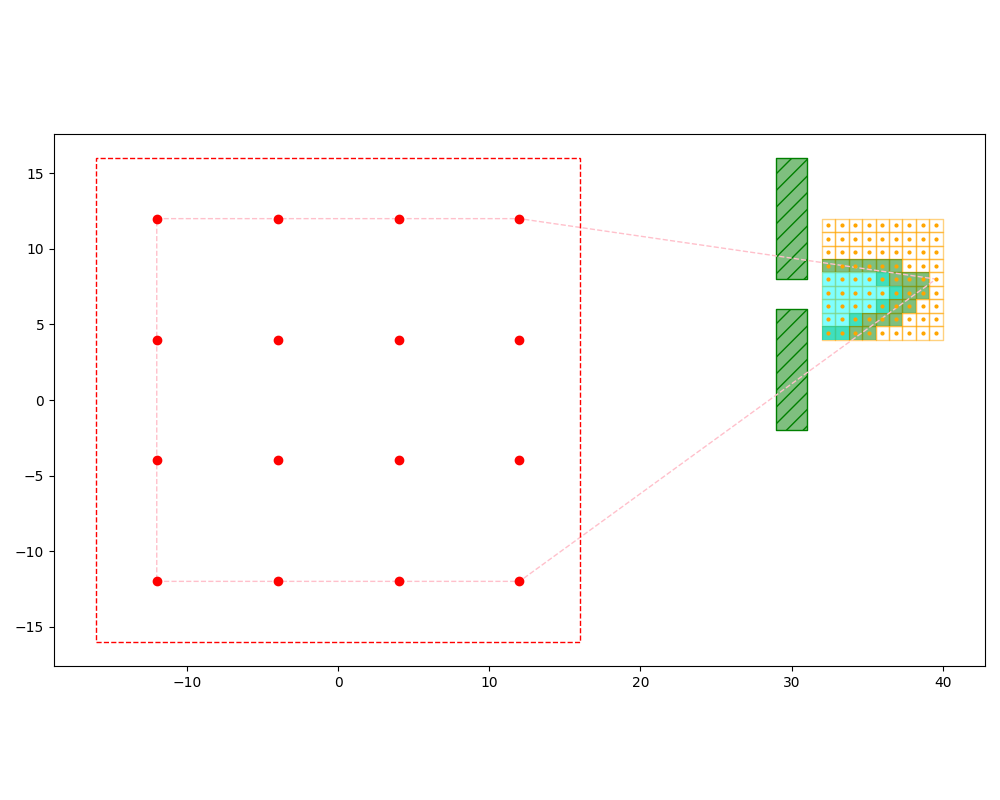

In [69]:
# define the subdivisions of the crystal
rect = torch.tensor(
    [[32, 4], [8, 0], [0, 8]],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([9, 9])

rect_subs = get_rect_subdivs(rect, xtal_nsubs)
plate_rects = torch.tensor(
    [
        [[29, 8], [2, 0], [0, 8]],
        [[29, -2], [2, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([8, 8])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor = get_fov_pixel_centers_2d(fov_npx, fov_mmppx)
pb_tensor = get_rects_center_2d(rect_subs)
rays = get_rays_2d(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2))

fov_verts = get_fov_verts_2d(fov_dims)
voxel_corners = get_convex_hull_2d(pa_tensor.view(-1, 2))


def if_rects_intersect_hull_2d(rects, hull, sub_center):
    # get the edges of the rectangles
    edges = get_rects_edges_2d(rects)
    index = torch.argsort(torch.linalg.norm(hull - sub_center, dim=1))
    ends = hull[index[1:5]]
    rays = get_rays_2d(ends, sub_center.view(1, 2))
    _, index = get_cuts_ray_on_edges_2d(rays, edges)
    return torch.unique(index[:, 1])


def if_rects_in_hull_2d(rects, hull):
    n_rects = rects.shape[0]
    points = get_rects_verts_2d(rects)
    n_hull = hull.shape[0]
    hull = get_verts_sorted_2d(hull)
    p0_tensor = hull.view(1, 1, -1, 2).expand(n_rects, 4, n_hull, 2)
    p1_tensor = (
        torch.vstack([hull[1:], hull[0]])
        .view(1, 1, -1, 2)
        .expand(n_rects, 4, n_hull, 2)
    )
    p2_tensor = points.view(n_rects, 4, 1, 2).expand(n_rects, 4, n_hull, 2)
    v1 = p1_tensor - p0_tensor
    v2 = p2_tensor - p0_tensor
    cross = torch.sign(
        v2[:, :, :, 0] * v1[:, :, :, 1] - v2[:, :, :, 1] * v1[:, :, :, 0]
    ).view(n_rects, 4, n_hull)
    return torch.where(
        torch.logical_or((cross > 0).all(dim=2), (cross < 0).all(dim=2)).all(
            dim=1
        )
    )


# i_list = torch.arange(0, rect_subs.shape[0])
i_list = [76]
for i in i_list:
    candidates = torch.vstack(
        (plate_rects, rect_subs[~torch.arange(rect_subs.shape[0]).eq(i)])
    )

    candidates_verts = get_rects_verts_2d(candidates)
    # hull = get_verts_sorted_2d(get_convex_hull_2d(torch.vstack((pb_tensor[i], voxel_corners))))
    hull = get_convex_hull_2d(torch.vstack((pb_tensor[i], voxel_corners)))
    valid_indices = if_rects_intersect_hull_2d(candidates, hull, pb_tensor[i])
    insid_indices = if_rects_in_hull_2d(candidates, hull)
    try:
        plt.close()
    except Exception as e:
        pass
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.set_aspect("equal")
    pstyles = [
        {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
        {"fc": "none", "ec": "orange", "alpha": 0.5, "label": "Subdivisions"},
    ]
    plot_scanner_2d(ax, [plate_rects, rect_subs], rays, pstyles)
    plot_rects(candidates[valid_indices], ax, fc="green", ec="none", alpha=0.5)
    plot_rects(candidates[insid_indices], ax, fc="cyan", ec="none", alpha=0.5)
    # ax.plot(result[:, 0], result[:, 1], "o", ms=4, c="purple")
    ax.add_patch(
        Polygon(
            hull,
            closed=True,
            fill=None,
            edgecolor="pink",
            linestyle="--",
            linewidth=1,
        )
    )
    ax.add_patch(
        Polygon(
            fov_verts,
            closed=True,
            fill=None,
            edgecolor="r",
            linestyle="--",
            linewidth=1,
        )
    )
    # plot_rays(ax, rays_cutted, color="purple", linewidth=1)
    # xlims = ax.get_xlim()
    # ylims = ax.get_ylim()
    # ax.set_xlim(ax.get_xlim()[0] - 10, ax.get_xlim()[1] + 10)
    # ax.set_ylim(ax.get_ylim()[0] - 10, ax.get_ylim()[1] + 10)

    ax.plot(
        pa_tensor.view(-1, 2)[:, 0], pa_tensor.view(-1, 2)[:, 1], "o", c="r"
    )
    plt.tight_layout()
    output_dir = (
        f"outputs/images/subdivs_{xtal_nsubs[0].item()}x{xtal_nsubs[1].item()}"
    )
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(f"{output_dir}/fix/{i:03d}.png")

shape of hull torch.Size([5, 2])
ends tensor([[-12.,  12.],
        [-12., -12.]])


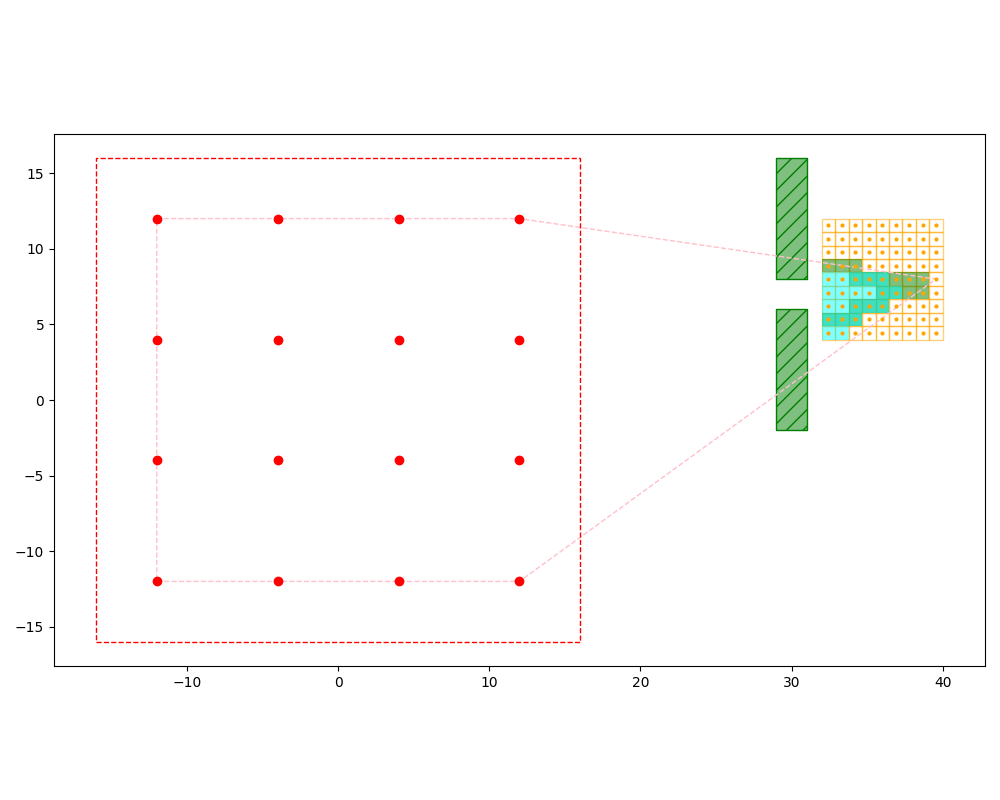

In [ ]:
# define the subdivisions of the crystal
rect = torch.tensor(
    [[32, 4], [8, 0], [0, 8]],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([9, 9])

rect_subs = get_rect_subdivs(rect, xtal_nsubs)
plate_rects = torch.tensor(
    [
        [[29, 8], [2, 0], [0, 8]],
        [[29, -2], [2, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([8, 8])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor = get_fov_pixel_centers_2d(fov_npx, fov_mmppx)
pb_tensor = get_rects_center_2d(rect_subs)
rays = get_rays_2d(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2))

fov_verts = get_fov_verts_2d(fov_dims)
voxel_corners = get_convex_hull_2d(pa_tensor.view(-1, 2))


def get_verts_sorted_by_angel_2d(
    vertices: torch.Tensor, ref_point: torch.Tensor
):
    # sort the vertices by angle to point ref_point
    rads = torch.atan2(
        vertices[:, 1] - ref_point[1], vertices[:, 0] - ref_point[0]
    )
    rads = (rads + 2 * torch.pi) % (2 * torch.pi)
    order = torch.argsort(rads)
    return vertices[order], rads


def get_three_p_cross(points):
    return (
        points[1, 0] * (points[2, 1] - points[0, 1])
        + points[2, 0] * (points[0, 1] - points[1, 1])
        + points[0, 0] * (points[1, 1] - points[2, 1])
    )


def get_convex_hull_2d(points: torch.Tensor) -> torch.Tensor:
    points = get_verts_sorted_2d(points)
    convex_hull = points[:2]
    for i in range(2, points.shape[0]):
        convex_hull = torch.vstack((convex_hull, points[i]))
        if (
            convex_hull.shape[0] > 1
            and get_three_p_cross(convex_hull[-3:]) <= 0
        ):
            convex_hull = torch.vstack([convex_hull[:-2], convex_hull[-1]])
    return convex_hull


def if_rects_in_hull_2d(rects, hull):
    points = get_rects_verts_2d(rects)
    n_rects = rects.shape[0]
    n_hull = hull.shape[0]
    hull = get_verts_sorted_2d(hull)
    p0_tensor = hull.unsqueeze(0).unsqueeze(0).expand(n_rects, 4, n_hull, 2)
    p1_tensor = (
        torch.vstack([hull[1:], hull[0]])
        .unsqueeze(0)
        .unsqueeze(0)
        .expand(n_rects, 4, n_hull, 2)
    )
    p2_tensor = points.unsqueeze(2).expand(-1, -1, n_hull, 2)
    v1 = p1_tensor - p0_tensor
    v2 = p2_tensor - p0_tensor
    cross = torch.sign(
        v2[:, :, :, 0] * v1[:, :, :, 1] - v2[:, :, :, 1] * v1[:, :, :, 0]
    ).view(n_rects, 4, n_hull)
    return torch.logical_or((cross > 0).all(dim=2), (cross < 0).all(dim=2)).all(
        dim=1
    )


def if_rects_intersect_hull_2d(rects, hull, sub_center):
    # get the edges of the rectangles
    edges = get_rects_edges_2d(rects)
    print("shape of hull", hull.shape)
    ends = get_verts_sorted_by_angel_2d(hull, sub_center)[[2, -2]]
    print("ends", ends)
    rays = get_rays_2d(ends, sub_center.view(1, 2))
    _, index = get_cuts_ray_on_edges_2d(rays, edges)
    return torch.unique(index[:, 1])


# def if_rects_intersect_hull_2d(rects, hull, sub_center):
#     # get the edges of the rectangles
#     edges = get_rects_edges_2d(rects)
#     index = torch.argsort(torch.linalg.norm(hull - sub_center, dim=1))
#     ends = hull[index[1:5]]
#     rays = get_rays_2d(ends, sub_center.view(1, 2))
#     _, index = get_cuts_ray_on_edges_2d(rays, edges)
#     return torch.unique(index[:, 1])

# i_list = torch.arange(0, rect_subs.shape[0])
i_list = [76]
for i in i_list:
    candidates = torch.vstack(
        (plate_rects, rect_subs[~torch.arange(rect_subs.shape[0]).eq(i)])
    )
    candidates_verts = get_rects_verts_2d(candidates)
    hull = get_convex_hull_2d(torch.vstack((pb_tensor[i], voxel_corners)))
    valid_indices = if_rects_intersect_hull_2d(candidates, hull, pb_tensor[i])
    insid_indices = if_rects_in_hull_2d(candidates, hull)
    try:
        plt.close()
    except Exception as e:
        pass
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    ax.set_aspect("equal")
    pstyles = [
        {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
        {"fc": "none", "ec": "orange", "alpha": 0.5, "label": "Subdivisions"},
    ]
    plot_scanner_2d(ax, [plate_rects, rect_subs], rays, pstyles)
    plot_rects(candidates[valid_indices], ax, fc="green", ec="none", alpha=0.5)
    plot_rects(candidates[insid_indices], ax, fc="cyan", ec="none", alpha=0.5)
    # ax.plot(result[:, 0], result[:, 1], "o", ms=4, c="purple")
    ax.add_patch(
        Polygon(
            hull,
            closed=True,
            fill=None,
            edgecolor="pink",
            linestyle="--",
            linewidth=1,
        )
    )
    ax.add_patch(
        Polygon(
            fov_verts,
            closed=True,
            fill=None,
            edgecolor="r",
            linestyle="--",
            linewidth=1,
        )
    )
    # plot_rays(ax, rays_cutted, color="purple", linewidth=1)
    # xlims = ax.get_xlim()
    # ylims = ax.get_ylim()
    # ax.set_xlim(ax.get_xlim()[0] - 10, ax.get_xlim()[1] + 10)
    # ax.set_ylim(ax.get_ylim()[0] - 10, ax.get_ylim()[1] + 10)

    ax.plot(
        pa_tensor.view(-1, 2)[:, 0], pa_tensor.view(-1, 2)[:, 1], "o", c="r"
    )
    plt.tight_layout()
    output_dir = (
        f"outputs/images/subdivs_{xtal_nsubs[0].item()}x{xtal_nsubs[1].item()}"
    )
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(f"{output_dir}/fixfix/{i:03d}.png")